<a href="https://colab.research.google.com/github/Nithin285/NLP/blob/main/4077_NLP_Assignment_13.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import nltk
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
df = pd.read_csv('SMSSpamCollection', sep='\t', names=['label', 'message'])

print("First 5 rows of the dataset:")
print(df.head())

print("\nShape of the dataset:")
print(df.shape)

First 5 rows of the dataset:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Shape of the dataset:
(5572, 2)


**Reasoning**:
The previous code failed because the 'SMSSpamCollection.txt' file was not found. I need to first download the dataset from a public URL to ensure it is available in the environment before attempting to load it.



In [ ]:
import requests
import os
import zipfile # Ensure zipfile is explicitly imported for clarity

# URL for the actual zip dataset from UCI ML Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
zip_file_name = "smsspamcollection.zip"
dataset_file_name = "SMSSpamCollection.txt"

# Download the zip file
print(f"Downloading {zip_file_name} from {url}...")
response = requests.get(url)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
with open(zip_file_name, 'wb') as f:
    f.write(response.content)
print(f"{zip_file_name} downloaded successfully.")

# Unzip the file
try:
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"Content of {zip_file_name} extracted.")
except zipfile.BadZipFile:
    print(f"Error: The downloaded file '{zip_file_name}' is not a valid zip file. Please check the URL and content.")
    if os.path.exists(zip_file_name):
        os.remove(zip_file_name) # Clean up the invalid file
    raise # Re-raise the exception to indicate failure

# Verify the file exists
if os.path.exists(dataset_file_name):
    print(f"{dataset_file_name} is now available.")
else:
    print(f"Error: {dataset_file_name} was not found after extraction. Please ensure it is present within the zip file.")

smsspamcollection.zip downloaded successfully.
Content of smsspamcollection.zip extracted.
Error: SMSSpamCollection.txt was not found after extraction. Please ensure it is present within the zip file.


In [ ]:
df['message'] = df['message'].str.lower()

print("Messages converted to lowercase.")
print(df.head())

Messages converted to lowercase.
  label                                            message
0   ham  go until jurong point, crazy.. available only ...
1   ham                      ok lar... joking wif u oni...
2  spam  free entry in 2 a wkly comp to win fa cup fina...
3   ham  u dun say so early hor... u c already then say...
4   ham  nah i don't think he goes to usf, he lives aro...


In [ ]:
import string

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['message'] = df['message'].apply(remove_punctuation)

print("Punctuation removed from messages.")
print(df.head())

Punctuation removed from messages.
  label                                            message
0   ham  go until jurong point crazy available only in ...
1   ham                            ok lar joking wif u oni
2  spam  free entry in 2 a wkly comp to win fa cup fina...
3   ham        u dun say so early hor u c already then say
4   ham  nah i dont think he goes to usf he lives aroun...


In [ ]:
import nltk
nltk.download('stopwords')

print("NLTK stopwords downloaded successfully.")

NLTK stopwords downloaded successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)

df['message'] = df['message'].apply(remove_stopwords)

print("Stopwords removed from messages.")
print(df.head())

Stopwords removed from messages.
  label                                            message
0   ham  go jurong point crazy available bugis n great ...
1   ham                            ok lar joking wif u oni
2  spam  free entry 2 wkly comp win fa cup final tkts 2...
3   ham                u dun say early hor u c already say
4   ham        nah dont think goes usf lives around though


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidfconverter = TfidfVectorizer()

# Fit and transform the 'message' column
X = tfidfconverter.fit_transform(df['message'])

print("TF-IDF feature vectors created successfully.")
print("Shape of TF-IDF matrix (X):", X.shape)

TF-IDF feature vectors created successfully.
Shape of TF-IDF matrix (X): (5572, 9437)


In [ ]:
from sklearn.model_selection import train_test_split

# Extract the 'label' column for classification
y = df['label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset split into training and testing sets successfully.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Dataset split into training and testing sets successfully.
Shape of X_train: (4457, 9437)
Shape of X_test: (1115, 9437)
Shape of y_train: (4457,)
Shape of y_test: (1115,)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Initialize Multinomial Naive Bayes classifier
classifier = MultinomialNB()

# Train the classifier using the training data
classifier.fit(X_train, y_train)

print("Multinomial Naive Bayes classifier initialized and trained successfully.")

Multinomial Naive Bayes classifier initialized and trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# Make predictions on the test set
y_pred = classifier.predict(X_test)

# Calculate and print evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='spam')
recall = recall_score(y_test, y_pred, pos_label='spam')
f1 = f1_score(y_test, y_pred, pos_label='spam')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Generate and print the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])
cm_df = pd.DataFrame(cm, index=['Actual Ham', 'Actual Spam'], columns=['Predicted Ham', 'Predicted Spam'])

print("\nConfusion Matrix:")
print(cm_df)

Accuracy: 0.9704
Precision: 1.0000
Recall: 0.7785
F1-Score: 0.8755

Confusion Matrix:
             Predicted Ham  Predicted Spam
Actual Ham             966               0
Actual Spam             33             116


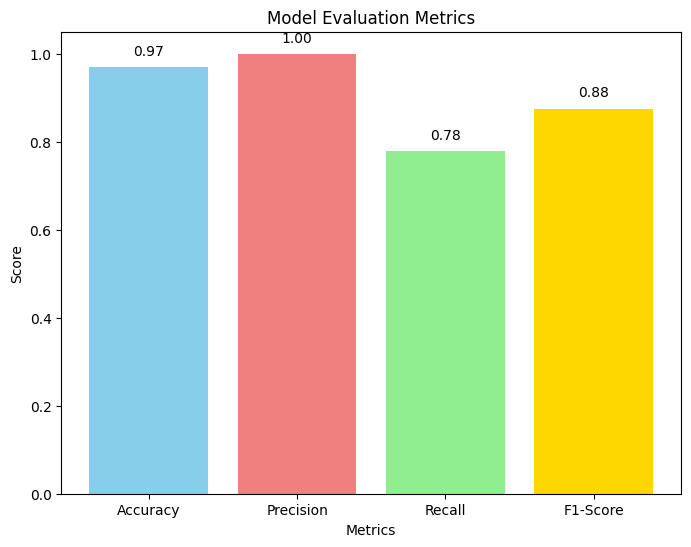

In [ ]:
import matplotlib.pyplot as plt

# Create lists for metric names and their corresponding values
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(metrics, scores, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Evaluation Metrics')
plt.ylim(0, 1.05) # Set y-axis limits from 0 to 1 with a little buffer

# Add score values on top of the bars for better readability
for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f'{score:.2f}', ha='center', va='bottom')

# Display the plot
plt.show()
